In [1]:
import sys
sys.path.append('../')
import scipy.io as sio
import mat73
import pandas as pd
import torch
import numpy as np
import torch.optim as optim
import torch.nn
import sklearn
import sklearn.metrics
import matplotlib.pyplot as plt
from alive_progress import alive_bar
from  utils.my_classes import dataset 
from torch.utils.data import DataLoader
import utils.DNN_functions as DNN_functions
import scipy
import random
import utils.AMSloss
from speechbrain.pretrained import SpeakerRecognition
import pickle
import os
from utils.my_classes import dataset
import utils.eval_metrics as eval_metrics
import copy
from speechbrain.pretrained import SpeakerRecognition

seed = 42  # You can choose any integer value as the seed
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
# Set seed for Python's random module
random.seed(seed)
# Set seed for NumPy
np.random.seed(seed)
# Set seed for PyTorch (CPU and GPU, if available)
if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
# Set deterministic flags for PyTorch (if available)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\__init__.py:177: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
The torchaudio backend is switched to 'soundfile'. Note that 'sox_io' is not supported on Windows.
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\speechbrain\utils\torch_audio_backend.py:22: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\torch\onnx\_internal\_beartype.py:35: UserWarning: unhashable type: 'list'
  warnings.warn(f"{e}")
The torchaudio backend is switched to 'soundfile'. Note that 'sox_io' is not supported on Windows.


In [2]:
#To get my GPU device - GTX 4070 :)
seed = 42  # You can choose any integer value as the seed
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');

if torch.cuda.is_available():
    print(torch.cuda.device_count())
    print(torch.cuda.device(0))
    print(torch.cuda.get_device_name(0))
    print(device)

1
NVIDIA GeForce RTX 4070
cuda


In [3]:
from ASV_utils.data_loading import *

models_folder = "ECAPA_TDNN/inference_models/"

data_path_male = "Data/not_normalize_all_features/male/"

data_path_female = "Data/not_normalize_all_features/female/"

male_embedded_groups_1_1,male_embedded_groups_1_2,male_embedded_groups_1_3,male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id,male_chosen_labels_3_1_speaker_id,male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex  = load_data_male(data_path_male)

female_embedded_groups_1_1,female_embedded_groups_1_2,female_embedded_groups_1_3,female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex  = load_data_female(data_path_female)

FileNotFoundError: [Errno 2] No such file or directory: 'Data/not_normalize_all_features/male/male_embedded_groups_1_1.mat'

In [4]:

import utils.my_functions as my_functions

columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)

female_embedded_groups_1_1 = female_embedded_groups_1_1[:,true_channels_indexes]
female_embedded_groups_1_2 = female_embedded_groups_1_2[:,true_channels_indexes]
female_embedded_groups_1_3 = female_embedded_groups_1_3[:,true_channels_indexes]

male_embedded_groups_1_1 = male_embedded_groups_1_1[:,true_channels_indexes]
male_embedded_groups_1_2 = male_embedded_groups_1_2[:,true_channels_indexes]
male_embedded_groups_1_3 = male_embedded_groups_1_3[:,true_channels_indexes]

In [5]:
from sklearn.preprocessing import StandardScaler
import re

your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract gammatone, gammatone_inv, channel number, and distance metric
    match = re.search(r'filter-(gammatone(?:_inv)?)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        gammatone = match.group(1)
        channel = int(match.group(2))
        distance_metric = match.group(3)

        # Assign a higher priority to distance_order, a medium priority to channels,
        # and lower priority to 'gammatone' and 'gammatone_inv'
        return (distance_metrics.index(distance_metric), channel, gammatone)

    else:
        # If the regex doesn't match, return the original item to maintain its position
        return (999, 999, "")

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    
male_embedded_groups_1_1 = male_embedded_groups_1_1[:,list(index_mapping.keys())]
male_embedded_groups_1_2 = male_embedded_groups_1_2[:,list(index_mapping.keys())]
male_embedded_groups_1_3 = male_embedded_groups_1_3[:,list(index_mapping.keys())]

female_embedded_groups_1_1 = female_embedded_groups_1_1[:,list(index_mapping.keys())]
female_embedded_groups_1_2 = female_embedded_groups_1_2[:,list(index_mapping.keys())]
female_embedded_groups_1_3 = female_embedded_groups_1_3[:,list(index_mapping.keys())]

In [6]:
scaler_male = StandardScaler(with_mean = True, with_std = True)
scaler_male.fit(male_embedded_groups_1_1)
mean_features = scaler_male.mean_
std_features = scaler_male.scale_
male_embedded_groups_1_1 = scaler_male.transform(male_embedded_groups_1_1)
male_embedded_groups_1_2 = scaler_male.transform(male_embedded_groups_1_2)
male_embedded_groups_1_3 = scaler_male.transform(male_embedded_groups_1_3)


scaler_female = StandardScaler(with_mean = True, with_std = True)
scaler_female.fit(female_embedded_groups_1_1)
mean_features = scaler_female.mean_
std_features = scaler_female.scale_
female_embedded_groups_1_1 = scaler_female.transform(female_embedded_groups_1_1)
female_embedded_groups_1_2 = scaler_female.transform(female_embedded_groups_1_2)
female_embedded_groups_1_3 = scaler_female.transform(female_embedded_groups_1_3)

In [7]:
embedded_groups_1_1,embedded_groups_1_2,embedded_groups_1_3,chosen_labels_1_1_is_spoofed,chosen_labels_2_1_is_spoofed,chosen_labels_3_1_is_spoofed,chosen_labels_numeric_1_1,chosen_labels_numeric_2_1,chosen_labels_numeric_3_1,chosen_labels_1_1_attack_logical,chosen_labels_2_1_attack_logical,chosen_labels_3_1_attack_logical,chosen_labels_1_1_name,chosen_labels_2_1_name,chosen_labels_3_1_name,chosen_labels_1_1_speaker_id,chosen_labels_2_1_speaker_id,chosen_labels_3_1_speaker_id,chosen_labels_1_1_sex,chosen_labels_2_1_sex,chosen_labels_3_1_sex    =  concatenate_data(male_embedded_groups_1_1,male_embedded_groups_1_2,male_embedded_groups_1_3,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id, male_chosen_labels_3_1_speaker_id,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_embedded_groups_1_1,female_embedded_groups_1_2,female_embedded_groups_1_3,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex)


In [8]:
train_dataset_all = dataset(data = embedded_groups_1_1 , is_spoofed = chosen_labels_1_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_1_1,
                        attack_logical = chosen_labels_1_1_attack_logical, name = chosen_labels_1_1_name , speaker_id = chosen_labels_1_1_speaker_id, sex = chosen_labels_1_1_sex ,data_transform = None , labels_transform = None);

Dev_dataset_all = dataset(data = embedded_groups_1_2 , is_spoofed = chosen_labels_2_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_2_1,
                        attack_logical = chosen_labels_2_1_attack_logical, name = chosen_labels_2_1_name , speaker_id = chosen_labels_2_1_speaker_id, sex = chosen_labels_2_1_sex ,  data_transform = None , labels_transform = None);


Eval_dataset_all = dataset(data = embedded_groups_1_3 , is_spoofed = chosen_labels_3_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_3_1,
                        attack_logical = chosen_labels_3_1_attack_logical, name = chosen_labels_3_1_name , speaker_id = chosen_labels_3_1_speaker_id, sex = chosen_labels_3_1_sex , data_transform = None , labels_transform = None);


In [9]:
from ASV_utils.data_loading import *


models_folder = "ECAPA_TDNN/inference_models/models_both_not_normalize/"

data_path_male = "Data/male_vs_female_DB_models/16_bits/none/male"

data_path_female = "Data/male_vs_female_DB_models/16_bits/none/female"

g_male_embedded_groups_1_1,g_male_embedded_groups_1_2,g_male_embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_  = load_data_male(data_path_male)

g_female_embedded_groups_1_1,g_female_embedded_groups_1_2,g_female_embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_  = load_data_female(data_path_female)

embedded_groups_1_1,embedded_groups_1_2,embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_    =  concatenate_data(g_male_embedded_groups_1_1,g_male_embedded_groups_1_2,g_male_embedded_groups_1_3,
                                                                                                                    male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,
                                                                                                                    male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,
                                                                                                                    male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,
                                                                                                                    male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,
                                                                                                                    male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id, male_chosen_labels_3_1_speaker_id,
                                                                                                                    male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex,
                                                                                                                    
                                                                                                                    g_female_embedded_groups_1_1,g_female_embedded_groups_1_2,g_female_embedded_groups_1_3,
                                                                                                                    female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,
                                                                                                                    female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,
                                                                                                                    female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,
                                                                                                                    female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,
                                                                                                                    female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,
                                                                                                                    female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex)



In [10]:



import utils.my_functions as my_functions

columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)

embedded_groups_1_1 = embedded_groups_1_1[:,true_channels_indexes]
embedded_groups_1_2 = embedded_groups_1_2[:,true_channels_indexes]
embedded_groups_1_3 = embedded_groups_1_3[:,true_channels_indexes]

from sklearn.preprocessing import StandardScaler
import re

your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract gammatone, gammatone_inv, channel number, and distance metric
    match = re.search(r'filter-(gammatone(?:_inv)?)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        gammatone = match.group(1)
        channel = int(match.group(2))
        distance_metric = match.group(3)

        # Assign a higher priority to distance_order, a medium priority to channels,
        # and lower priority to 'gammatone' and 'gammatone_inv'
        return (distance_metrics.index(distance_metric), channel, gammatone)

    else:
        # If the regex doesn't match, return the original item to maintain its position
        return (999, 999, "")

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    

embedded_groups_1_1 = embedded_groups_1_1[:,list(index_mapping.keys())]
embedded_groups_1_2 = embedded_groups_1_2[:,list(index_mapping.keys())]
embedded_groups_1_3 = embedded_groups_1_3[:,list(index_mapping.keys())]


scaler = StandardScaler(with_mean = True, with_std = True)
scaler.fit(embedded_groups_1_1)
mean_features = scaler.mean_
std_features = scaler.scale_

embedded_groups_1_1 = scaler.transform(embedded_groups_1_1)
embedded_groups_1_2 = scaler.transform(embedded_groups_1_2)
embedded_groups_1_3 = scaler.transform(embedded_groups_1_3)

train_dataset_all.data_for_gender_classification = embedded_groups_1_1
Dev_dataset_all.data_for_gender_classification   = embedded_groups_1_2
Eval_dataset_all.data_for_gender_classification  = embedded_groups_1_3


train_dataset_all.sex = pd.Series([elem[0] for elem in train_dataset_all.sex])
Dev_dataset_all.sex = pd.Series([elem[0] for elem in Dev_dataset_all.sex])
Eval_dataset_all.sex = pd.Series([elem[0] for elem in Eval_dataset_all.sex])


train_dataset_all.name = pd.Series([name[0] for name in train_dataset_all.name])
Dev_dataset_all.name = pd.Series([name[0] for name in Dev_dataset_all.name])
Eval_dataset_all.name = pd.Series([name[0] for name in Eval_dataset_all.name])

In [11]:
import torchaudio
from speechbrain.pretrained import EncoderClassifier

# load the model - the moodel that check if it's female or male
with open(os.path.join(models_folder,"gender_XGB_model_both_norm_male_vs_female_db_models.pkl"), 'rb') as fp:
#with open(os.path.join(models_folder,"gender_XGB_model_both_norm_male_vs_female_db_models.pkl"), 'rb') as fp:
    gender_model = pickle.load(fp)
    
# load the model - the model that check if it's the sampe speaker or not
verification_model = SpeakerRecognition.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir='./ECAPA_TDNN/pretrained_models/spkrec-ecapa-voxceleb',run_opts={"device":"cuda"} )

classifier = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir='./ECAPA_TDNN/pretrained_models/spkrec-ecapa-voxceleb',run_opts={"device":"cuda"})



In [12]:
import pickle
from ASV_utils.ASV_my_functions import *
# Load the embeddings file:

with open('./ECAPA_TDNN/embeddings/dev_embedding_ecapa_voxceleb_flac.pkl', 'rb') as file:
    list_dev_files,embeddings_dev = pickle.load(file)
    list_dev_files = [name.rstrip('.flac') for name in list_dev_files]
    
with open('./ECAPA_TDNN/embeddings/eval_embedding_ecapa_voxceleb_flac.pkl', 'rb') as file:
    list_eval_files,embeddings_eval = pickle.load(file)
    list_eval_files = [name.rstrip('.flac') for name in list_eval_files]


embeddings_dev =[emb.cpu() for emb in embeddings_dev]
embeddings_dev = np.concatenate(embeddings_dev, axis=0)
embeddings_eval =[emb.cpu() for emb in embeddings_eval]
embeddings_eval = np.concatenate(embeddings_eval, axis=0)


path_enrollment_dev_female = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.female.trn.txt"

path_enrollment_dev_male = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.male.trn.txt"

path_enrollment_eval_female = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.female.trn.txt"

path_enrollment_eval_male = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.male.trn.txt"


enrollment_dev_female = make_enrollment(path_enrollment_dev_female,"female")

enrollment_dev_male = make_enrollment(path_enrollment_dev_male,"male")

enrollment_eval_female = make_enrollment(path_enrollment_eval_female,"female")

enrollment_eval_male = make_enrollment(path_enrollment_eval_male,"male")

enrollment_dev_female = extract_embeddings(list_dev_files,embeddings_dev,enrollment_dev_female)
list_dev_files,embeddings_dev = remove_enrollment_embeddings_from_embeddings_list(list_dev_files,embeddings_dev,enrollment_dev_female)

enrollment_dev_male = extract_embeddings(list_dev_files,embeddings_dev,enrollment_dev_male)
list_dev_files,embeddings_dev = remove_enrollment_embeddings_from_embeddings_list(list_dev_files,embeddings_dev,enrollment_dev_male)

enrollment_eval_female = extract_embeddings(list_eval_files,embeddings_eval,enrollment_eval_female)
list_eval_files,embeddings_eval = remove_enrollment_embeddings_from_embeddings_list(list_eval_files,embeddings_eval,enrollment_eval_female)

enrollment_eval_male = extract_embeddings(list_eval_files,embeddings_eval,enrollment_eval_male)
list_eval_files,embeddings_eval = remove_enrollment_embeddings_from_embeddings_list(list_eval_files,embeddings_eval,enrollment_eval_male)


In [13]:
from ASV_utils.dcf_my_functions import dcf_formula

# read the protocol files

path_dev_female_protocol ="./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.female.trl.txt"

path_dev_male_protocol ="./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.male.trl.txt"

path_eval_female_protocol ="./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.female.trl.txt"

path_eval_male_protocol ="./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.male.trl.txt"

path_dev_all_protocol ="./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.gi.trl.txt"

path_eval_all_protocol ="./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.gi.trl.txt"

df_dev_female_protocol = pd.read_csv(path_dev_female_protocol, delimiter=' ', names=['speaker_id', 'audio_filename', 'attack_type', 'label'])

df_dev_male_protocol = pd.read_csv(path_dev_male_protocol, delimiter=' ', names=['speaker_id', 'audio_filename', 'attack_type', 'label'])

df_dev_all_protocol = pd.read_csv(path_dev_all_protocol, delimiter=' ', names=['speaker_id', 'audio_filename', 'attack_type', 'label'])

df_eval_female_protocol = pd.read_csv(path_eval_female_protocol, delimiter=' ', names=['speaker_id', 'audio_filename', 'attack_type', 'label'])

df_eval_male_protocol = pd.read_csv(path_eval_male_protocol, delimiter=' ', names=['speaker_id', 'audio_filename', 'attack_type', 'label'])

df_eval_all_protocol = pd.read_csv(path_eval_all_protocol, delimiter=' ', names=['speaker_id', 'audio_filename', 'attack_type', 'label'])


# False alarm rate of the ASV system (nontarget trials that were falsely accepted) - depent on the ASV system result
Pfa_asv = 0.5 #number of nontarget that were falsely accepted / number of nontarget samples

# Miss rate of the ASV system (fraction of genuine cases falsely rejected) - depent on the ASV system result
Pmiss_asv = 0.5  #number of target that were falsely rejected / number of target samples

Prior_target =  0.99

Prior_non_target = 1-Prior_target

cost_model_dcf = {
    'Cmiss_asv': 1,      # Cost of ASV falsely rejecting target
    'Cfa_asv': 10,       # Cost of ASV falsely accepting nontarget
}


## check the DCF for the eval set
dcf_formula(Pfa_asv,Pmiss_asv,Prior_target,Prior_non_target,cost_model_dcf,is_print=True)

The DCF is:  0.545


0.545

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

def plotting_probability_histogram(nontarget_scores,target_scores,spoof_scores = None,num_bins=100,colors=['yellow', 'purple'],data_name=None):
    if data_name is None:
        raise Exception("Please insert data name")
    if spoof_scores is None:
        if len(colors) != 2:
            raise Exception("Please insert 2 colors")
        plt.figure()
        sns.histplot(nontarget_scores, kde=True, stat='probability', bins=num_bins, color=colors[0], linewidth=1)# Add labels and title
        sns.histplot(target_scores, kde=True, stat='probability', bins=num_bins, color=colors[1], linewidth=1)# Add labels and title
        plt.legend(['bonafide','spoof'])
        plt.xlabel('scores')
        plt.ylabel('probability')
        
        plt.title(f"Probability of target scores and Probability of Non-target scores on " + data_name)
        # Add legend
        # Show the plot
        plt.show()

        plt.figure()
        sns.histplot([nontarget_scores.to_numpy(), target_scores.to_numpy()], kde=True, stat='probability', bins=num_bins, palette=colors, linewidth=1)# Add labels and title
        plt.legend(['target_scores','nontarget scores'])
        plt.xlabel('scores')
        plt.ylabel('probability')
        plt.title(f"Probability over target scores and Non-target scores on " + data_name)
        # Add legend
        # Show the plot
        plt.show()
    else:
        if len(colors) != 3:
            raise Exception("Please insert 2 colors")
        plt.figure()
        sns.histplot(nontarget_scores, kde=True, stat='probability', bins=num_bins, color=colors[0], linewidth=1)# Add labels and title
        sns.histplot(target_scores, kde=True, stat='probability', bins=num_bins, color=colors[1], linewidth=1)# Add labels and title
        sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color=colors[2], linewidth=1)# Add labels and title
        plt.legend(['nontarget scores','target scores','spoof scores'])
        plt.xlabel('scores')
        plt.ylabel('probability')
        plt.title(f"Probability of target scores and Probability of Non-target scores and Probability of spoof scores on " + data_name)
        plt.show()
        
        plt.figure()
        sns.histplot([nontarget_scores.to_numpy(), target_scores.to_numpy(),spoof_scores.to_numpy()], kde=True, stat='probability', bins=100, palette=colors, linewidth=1)# Add labels and title
        plt.legend(['spoof scores','target_scores','nontarget scores'])
        plt.xlabel('scores')
        plt.ylabel('probability')
        plt.title(f"Probability over target scores and Non-target scores and Probability of spoof scores on " + data_name)
        # Show the plot
        plt.show()

import numpy as np
import matplotlib.pyplot as plt

def plotting_eer_and_dcf(asv_score_list, dcf_list, frr, far, eer, thr_eer, data_name=None):
    if data_name is None:
        raise Exception("Please insert data name")
    
    # Plot DCF metric
    plt.figure()
    plt.plot(asv_score_list, dcf_list, label='DCF vs threshold')
    minDCF_index = np.argmin(np.array(dcf_list))
    plt.plot(asv_score_list[minDCF_index], dcf_list[minDCF_index], color='red', marker='o',
             label=f'minDCF={dcf_list[minDCF_index]:.3f}, threshold={asv_score_list[minDCF_index]:.3f}')
    plt.title(f"DCF metric on " + data_name)
    plt.ylabel("DCF metric")
    plt.xlabel("ASV threshold")
    plt.legend(loc='lower right')
    plt.show()

    # Plot DET curve with log scale
    plt.figure()
    plt.plot(far, frr, label='DET curve')
    plt.scatter([eer], [eer], color='red', marker='o',
                label=f'EER ({100 * eer:.3f}%, {100 * eer:.3f}%), threshold EER = {thr_eer:.3f}')
    plt.xscale('log')
    plt.yscale('log')
    plt.ylabel("False Rejection Rate (FRR)")
    plt.xlabel("False Acceptance Rate (FAR)")
    plt.title("DET curve on " + data_name)
    plt.legend(loc='upper right')
    #plt.grid(which="both", linestyle="--", linewidth=0.5)
    plt.show()


In [19]:
def plotting_probability_histogram_TTS_and_VC(nontarget_scores,target_scores,TTS_scores,VC_scores,combine_TTS_VC_scores,num_bins=100,colors=['yellow', 'purple'],data_name=None):
        if data_name is None:
            raise Exception("Please insert data name")
        if len(colors) != 5:
            raise Exception("Please insert 5 colors")
        if combine_TTS_VC_scores is None:
            plt.figure()
            sns.histplot(nontarget_scores, kde=True, stat='probability', bins=num_bins, color=colors[0], linewidth=1)# Add labels and title
            sns.histplot(target_scores, kde=True, stat='probability', bins=num_bins, color=colors[1], linewidth=1)# Add labels and title
            sns.histplot(TTS_scores, kde=True, stat='probability', bins=num_bins, color=colors[2], linewidth=1)# Add labels and title
            sns.histplot(VC_scores, kde=True, stat='probability', bins=num_bins, color=colors[3], linewidth=1)# Add labels and title
            plt.legend(['nontarget scores','target scores','TTS scores','VC scores'])
            plt.xlabel('scores')
            plt.ylabel('probability')
            plt.title(f"Scores for Target and Non-Target, TTS, VC " + data_name)
            plt.show()
            
            plt.figure()
            sns.histplot([nontarget_scores.to_numpy(), target_scores.to_numpy(),TTS_scores.to_numpy(),VC_scores.to_numpy()], kde=True, stat='probability', bins=100, palette=colors, linewidth=1)# Add labels and title
            plt.legend(['VC scores','TTS scores','target_scores','nontarget scores'])
            plt.xlabel('scores')
            plt.ylabel('probability')
            plt.title(f"Scores for Target and Non-Target, TTS, VC "  + data_name)
            # Show the plot
            plt.show()
        else:
            plt.figure()
            sns.histplot(nontarget_scores, kde=True, stat='probability', bins=num_bins, color=colors[0], linewidth=1)# Add labels and title
            sns.histplot(target_scores, kde=True, stat='probability', bins=num_bins, color=colors[1], linewidth=1)# Add labels and title
            sns.histplot(TTS_scores, kde=True, stat='probability', bins=num_bins, color=colors[2], linewidth=1)# Add labels and title
            sns.histplot(VC_scores, kde=True, stat='probability', bins=num_bins, color=colors[3], linewidth=1)# Add labels and title
            sns.histplot(combine_TTS_VC_scores, kde=True, stat='probability', bins=num_bins, color=colors[4], linewidth=1)# Add labels and title
            
            plt.legend(['nontarget scores','target scores','TTS scores','VC scores','combine TTS and VC scores'])
            plt.xlabel('scores')
            plt.ylabel('probability')
            plt.title(f"Scores for Target and Non-Target, TTS, VC, and Combined TTS-VC "  + data_name)
            plt.show()
            
            plt.figure()
            sns.histplot([nontarget_scores.to_numpy(), target_scores.to_numpy(),TTS_scores.to_numpy(),VC_scores.to_numpy(),combine_TTS_VC_scores.to_numpy()], kde=True, stat='probability', bins=100, palette=colors, linewidth=1)# Add labels and title
            plt.legend(['combine TTS and VC scores','VC scores','TTS scores','target_scores','nontarget scores'])
            plt.xlabel('scores')
            plt.ylabel('probability')
            plt.title(f"Scores for Target and Non-Target, TTS, VC, and Combined TTS-VC "  + data_name)
            # Show the plot
            plt.show()

In [16]:
'''
import torch
import torchaudio
def calculate_dcf_avg_score(list_files,df_protocol,enrollment,embeddings,dataset_all): # CALCULATE THE DCF FOR THE ASV SYSTEM
    
    thr_gender = 0.5
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');
    #path_names = pd.Series(np.array(list_files)) # Get the path names of the data set # Get the path names of the data set
    all_speakers_id_enroll = np.array(enrollment.get_all_speakers_id())  # Get all the speakers id in the enrollment data set
    
    labels_list = []; avg_scores_pred_list = []; # labels_list and scores_list for each asv score
    gender_list = [];
    gender_pred_list =[]
    audio_filename_list = []; speaker_id_list = []; attack_type_list = [];  # audio_filename_list and speaker_id_list for each asv score
    for _, row in tqdm.tqdm(df_protocol.iterrows(), total=len(df_protocol)): # over each row in the protocol file
        
        audio_filename = row['audio_filename'] # Get the audio filename
        speaker_id = row['speaker_id'] # Get the speaker id
        attack_type = row['attack_type'] # Get the attack type
        try:
            #index_embeddings = path_names.str.contains(audio_filename) # Get the index of the current audio filename
            index_time_embeddings = dataset_all.name.str.contains(audio_filename) # Get the index of the current audio filename
            index_time_embeddings = np.where(index_time_embeddings.values == True)
            if len(index_time_embeddings) > 1 or len(index_time_embeddings) == 0: #problem with the index
                raise Exception("The audio filename is not in the embeddings data set")
        except Exception as e:    
            raise Exception("The speaker id is not in the enrollment data set")
        
        with torch.no_grad():
            if gender_model.predict_proba([dataset_all.data_for_gender_classification[index_time_embeddings[0][0]]])[:,1] > thr_gender: #need to normalize the data
                its_male = True
            else:
                its_male = False
        
        gender = dataset_all.sex.values[index_time_embeddings[0][0]]
        curr_signal,_ = torchaudio.load(str(dataset_all.name.values[index_time_embeddings[0][0]]))
        
        label = row['label'] # Get the label of the current audio filename
        find_speaker_in_enroll = False # initialize the find_speaker_in_enroll flag
        list_scores_speaker = [] # initialize the list of scores speaker
        for index_speaker,embedding_in_enroll_per_speaker in enumerate(enrollment.get_all_enrollment_embeddings()): # over each speaker in the enrollment data set
            embedding_in_enroll_per_speaker = np.array(embedding_in_enroll_per_speaker)
            for _,embedding_in_enroll in enumerate(embedding_in_enroll_per_speaker):
                if speaker_id == all_speakers_id_enroll[index_speaker]: # i know that the speaker id of the inferece input
                    find_speaker_in_enroll = True
                    
                    curr_embedding = classifier.encode_batch(curr_signal.to(device)).cpu().numpy().squeeze(0)
                    
                    score = cosine_similarity(embedding_in_enroll.squeeze().reshape(1, -1), curr_embedding.reshape(1, -1)) # calculate the cosine similarity between the current embedding and the enrollment embedding
                    list_scores_speaker.append(score.item()) # append the score to the list of scores
        
        avg_score_pred = np.average(list_scores_speaker, axis = 0) # calculate the average score 
        
        if find_speaker_in_enroll == False:
            raise Exception("The speaker id is not in the enrollment data set")
        
        gender_list.append(gender)
        labels_list.append(label) # the current embedding is in the enrollment embeddings
        avg_scores_pred_list.append(avg_score_pred) # the score of the current embedding with the enrollment embedding
        audio_filename_list.append(audio_filename)
        speaker_id_list.append(speaker_id)  
        attack_type_list.append(attack_type)                      
        gender_pred_list.append(its_male)
        
    df_results = pd.DataFrame({'label_ground_truth': labels_list,'pred_scores': avg_scores_pred_list,'audio_filename': audio_filename_list,'speaker_id': speaker_id_list,'attack_type': attack_type_list, 'gender': gender_list,'gender_pred': gender_pred_list})
    
        
    return df_results
'''

'\nimport torch\nimport torchaudio\ndef calculate_dcf_avg_score(list_files,df_protocol,enrollment,embeddings,dataset_all): # CALCULATE THE DCF FOR THE ASV SYSTEM\n    \n    thr_gender = 0.5\n    \n    device = torch.device(\'cuda\' if torch.cuda.is_available() else \'cpu\');\n    #path_names = pd.Series(np.array(list_files)) # Get the path names of the data set # Get the path names of the data set\n    all_speakers_id_enroll = np.array(enrollment.get_all_speakers_id())  # Get all the speakers id in the enrollment data set\n    \n    labels_list = []; avg_scores_pred_list = []; # labels_list and scores_list for each asv score\n    gender_list = [];\n    gender_pred_list =[]\n    audio_filename_list = []; speaker_id_list = []; attack_type_list = [];  # audio_filename_list and speaker_id_list for each asv score\n    for _, row in tqdm.tqdm(df_protocol.iterrows(), total=len(df_protocol)): # over each row in the protocol file\n        \n        audio_filename = row[\'audio_filename\'] # Get

In [17]:
import torch
import torchaudio
def calculate_dcf_avg_score(list_files,df_protocol,enrollment,embeddings,dataset_all): # CALCULATE THE DCF FOR THE ASV SYSTEM
    
    thr_gender = 0.5
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');
    path_names = pd.Series(np.array(list_files)) # Get the path names of the data set # Get the path names of the data set
    all_speakers_id_enroll = np.array(enrollment.get_all_speakers_id())  # Get all the speakers id in the enrollment data set
    
    labels_list = []; avg_scores_pred_list = []; # labels_list and scores_list for each asv score
    gender_list = [];
    gender_pred_list =[]
    audio_filename_list = []; speaker_id_list = []; attack_type_list = [];  # audio_filename_list and speaker_id_list for each asv score
    for _, row in tqdm.tqdm(df_protocol.iterrows(), total=len(df_protocol)): # over each row in the protocol file
        
        audio_filename = row['audio_filename'] # Get the audio filename
        speaker_id = row['speaker_id'] # Get the speaker id
        attack_type = row['attack_type'] # Get the attack type
        try:
            #index_embeddings = path_names.str.contains(audio_filename) # Get the index of the current audio filename
            index_time_embeddings = dataset_all.name.str.contains(audio_filename) # Get the index of the current audio filename
            index_time_embeddings = np.where(index_time_embeddings.values == True)
            if len(index_time_embeddings) > 1 or len(index_time_embeddings) == 0: #problem with the index
                raise Exception("The audio filename is not in the embeddings data set")
        except Exception as e:    
            raise Exception("The speaker id is not in the enrollment data set")
        

        try:
            index_embeddings = path_names.str.contains(audio_filename) # Get the index of the current audio filename
        except Exception as e:    
            raise Exception("The speaker id is not in the enrollment data set")
    
        curr_embedding = embeddings[index_embeddings] # Get the current embedding
        with torch.no_grad():
            if gender_model.predict_proba([dataset_all.data_for_gender_classification[index_time_embeddings[0][0]]])[:,1] > thr_gender: #need to normalize the data
                its_male = True
            else:
                its_male = False
        
        gender = dataset_all.sex.values[index_time_embeddings[0][0]]
        
        
        label = row['label'] # Get the label of the current audio filename
        find_speaker_in_enroll = False # initialize the find_speaker_in_enroll flag
        list_scores_speaker = [] # initialize the list of scores speaker
        for index_speaker,embedding_in_enroll_per_speaker in enumerate(enrollment.get_all_enrollment_embeddings()): # over each speaker in the enrollment data set
            embedding_in_enroll_per_speaker = np.array(embedding_in_enroll_per_speaker)
            for _,embedding_in_enroll in enumerate(embedding_in_enroll_per_speaker):
                if speaker_id == all_speakers_id_enroll[index_speaker]: # i know that the speaker id of the inferece input
                    find_speaker_in_enroll = True
                    
                    
                    score = cosine_similarity(embedding_in_enroll.squeeze().reshape(1, -1), curr_embedding.reshape(1, -1)) # calculate the cosine similarity between the current embedding and the enrollment embedding
                    list_scores_speaker.append(score.item()) # append the score to the list of scores
        
        avg_score_pred = np.average(list_scores_speaker, axis = 0) # calculate the average score 
        
        if find_speaker_in_enroll == False:
            raise Exception("The speaker id is not in the enrollment data set")
        
        gender_list.append(gender)
        labels_list.append(label) # the current embedding is in the enrollment embeddings
        avg_scores_pred_list.append(avg_score_pred) # the score of the current embedding with the enrollment embedding
        audio_filename_list.append(audio_filename)
        speaker_id_list.append(speaker_id)  
        attack_type_list.append(attack_type)                      
        gender_pred_list.append(its_male)
        
    df_results = pd.DataFrame({'label_ground_truth': labels_list,'pred_scores': avg_scores_pred_list,'audio_filename': audio_filename_list,'speaker_id': speaker_id_list,'attack_type': attack_type_list, 'gender': gender_list,'gender_pred': gender_pred_list})
    
        
    return df_results

In [18]:
!!!

["'!' is not recognized as an internal or external command,",
 'operable program or batch file.']

In [19]:
from ASV_utils.dcf_my_functions import calculate_dcf
import matplotlib.pyplot as plt

Prior_target =  0.99

Prior_non_target = 1 - Prior_target

dcf_list_dev_all = []
is_print = True

cost_model_dcf = {
    'Cmiss_asv': 1,      # Cost of ASV falsely rejecting target
    'Cfa_asv': 10,       # Cost of ASV falsely accepting nontarget
}

all_enrollement_dev = enrollment_dev_male + enrollment_dev_female 

# for all eval
asv_thr_list = np.arange(0, 1.01, 0.001).tolist()
'''
results_list_dev_all = calculate_dcf_avg_score(list_dev_files,df_dev_all_protocol,all_enrollement_dev,embeddings_dev,Dev_dataset_all)

import pickle
file_path = 'asv_results_dev_fixed_all.pickle'

# Open the file in binary write mode and dump the data
with open(file_path, 'wb') as f:
    pickle.dump(results_list_dev_all, f)
'''


"\nresults_list_dev_all = calculate_dcf_avg_score(list_dev_files,df_dev_all_protocol,all_enrollement_dev,embeddings_dev,Dev_dataset_all)\n\nimport pickle\nfile_path = 'asv_results_dev_fixed_all.pickle'\n\n# Open the file in binary write mode and dump the data\nwith open(file_path, 'wb') as f:\n    pickle.dump(results_list_dev_all, f)\n"

In [20]:
import pickle
file_path = 'asv_results_dev_fixed_all.pkl'
results_list_dev_all = pickle.load(open(file_path, 'rb'))


In [21]:
target_scores = results_list_dev_all.loc[results_list_dev_all['label_ground_truth'] == "target"]["pred_scores"]
nontarget_scores = results_list_dev_all.loc[results_list_dev_all['label_ground_truth'] == "nontarget"]["pred_scores"]

eer, thr_eer, frr, far = eval_metrics.compute_eer(target_scores,nontarget_scores)
    
for asv_thr in asv_thr_list: # over each asv score

    print("current asv score is: ",asv_thr)

    Pfa_asv, Pmiss_asv, _ , _ = eval_metrics.obtain_asv_error_rates(target_scores,nontarget_scores,np.array([]),asv_thr)
    dcf = dcf_formula(Pfa_asv,Pmiss_asv,Prior_target = Prior_target,Prior_non_target= Prior_non_target,cost_model_dcf=cost_model_dcf,is_print=is_print)
    dcf_list_dev_all.append(dcf)
    
    
print("the EER is: ",eer)
print("the threshold of the EER is: ",thr_eer)
minDCF_index = np.argmin(np.array(dcf_list_dev_all))
print("the minDCF is:",dcf_list_dev_all[minDCF_index])
print("the threshold of the minDCF is: ",asv_thr_list[minDCF_index])

current asv score is:  0.0
The DCF is:  0.0925277392510403
current asv score is:  0.001
The DCF is:  0.09249306518724003
current asv score is:  0.002
The DCF is:  0.09235436893203891
current asv score is:  0.003
The DCF is:  0.09223300970873795
current asv score is:  0.004
The DCF is:  0.09204230235783642
current asv score is:  0.005
The DCF is:  0.09186893203883503
current asv score is:  0.006
The DCF is:  0.09173023578363391
current asv score is:  0.007
The DCF is:  0.0915395284327324
current asv score is:  0.008
The DCF is:  0.09131414701803059
current asv score is:  0.009000000000000001
The DCF is:  0.09112343966712907
current asv score is:  0.01
The DCF is:  0.0910020804438281
current asv score is:  0.011
The DCF is:  0.09088072122052714
current asv score is:  0.012
The DCF is:  0.09070735090152575
current asv score is:  0.013000000000000001
The DCF is:  0.09048196948682394
current asv score is:  0.014
The DCF is:  0.09025658807212214
current asv score is:  0.015
The DCF is:  0.09

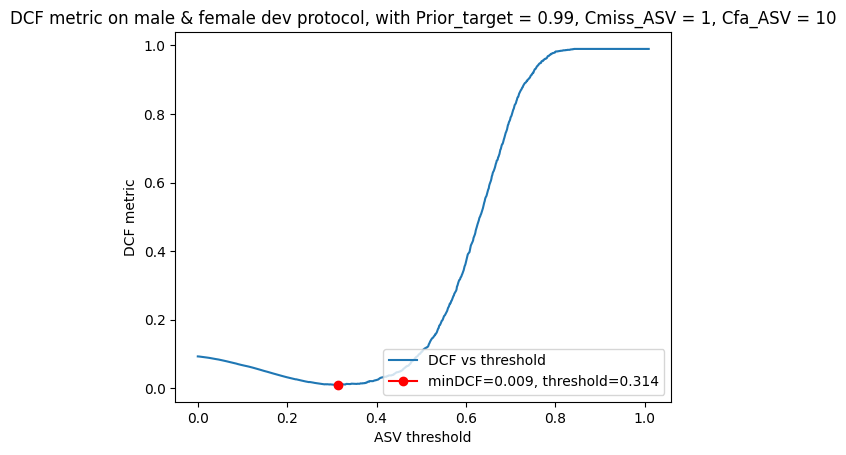

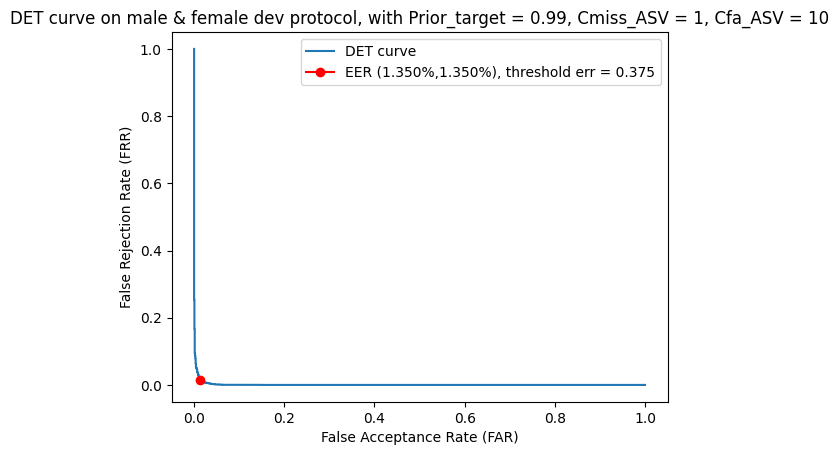

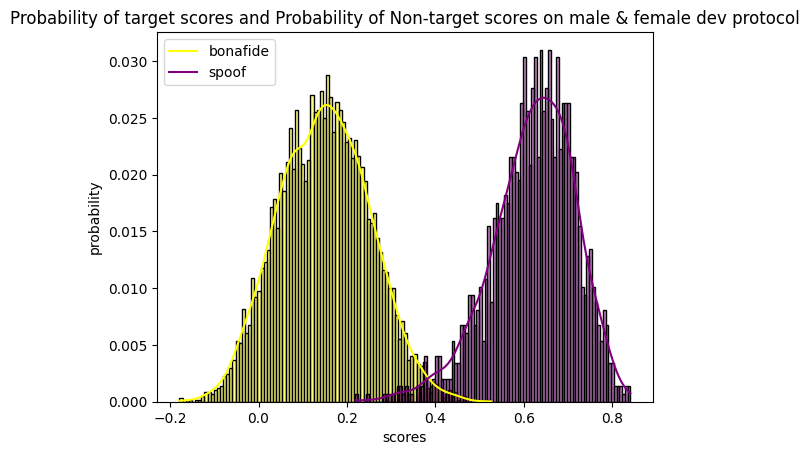

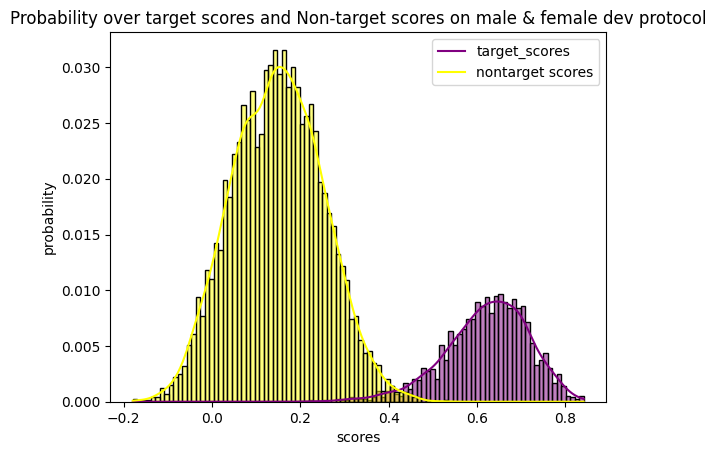

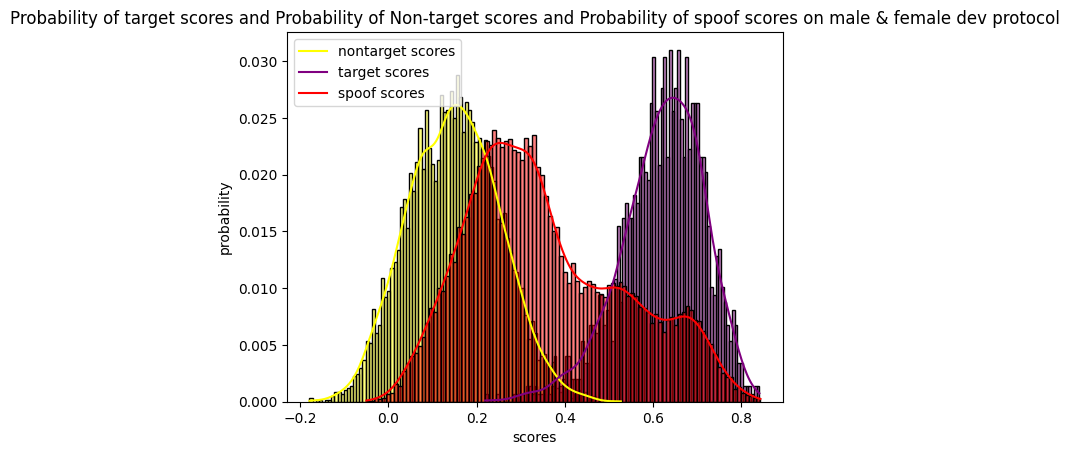

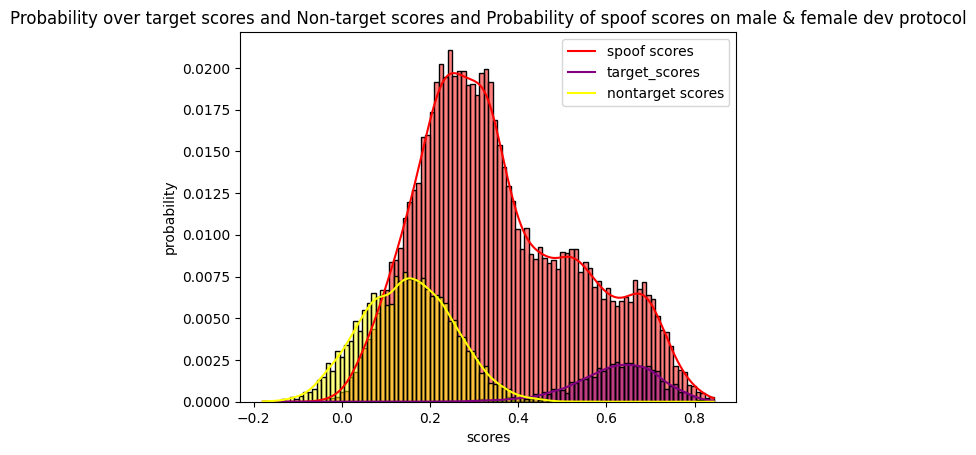

In [22]:
plotting_eer_and_dcf(asv_thr_list,dcf_list_dev_all,frr,far,eer,thr_eer,data_name = f"male & female dev protocol, with Prior_target = {Prior_target}, Cmiss_ASV = {cost_model_dcf['Cmiss_asv']}, Cfa_ASV = {cost_model_dcf['Cfa_asv']}")

target_scores = results_list_dev_all.loc[results_list_dev_all['label_ground_truth'] == "target"]["pred_scores"]
nontarget_scores = results_list_dev_all.loc[results_list_dev_all['label_ground_truth'] == "nontarget"]["pred_scores"]
spoof_scores = results_list_dev_all.loc[results_list_dev_all['label_ground_truth'] == "spoof"]["pred_scores"]

# Plot the histograms
plotting_probability_histogram(nontarget_scores,target_scores,num_bins=100,colors=['yellow', 'purple'],data_name = f"male & female dev protocol")
plotting_probability_histogram(nontarget_scores,target_scores,spoof_scores,num_bins=100,colors=['yellow', 'purple','red'],data_name = f"male & female dev protocol")


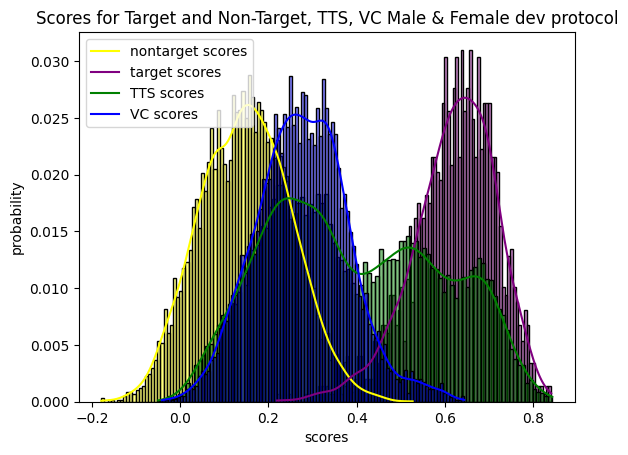

C:\Users\avish\AppData\Local\Temp\ipykernel_17452\981316493.py:19: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.histplot([nontarget_scores.to_numpy(), target_scores.to_numpy(),TTS_scores.to_numpy(),VC_scores.to_numpy()], kde=True, stat='probability', bins=100, palette=colors, linewidth=1)# Add labels and title


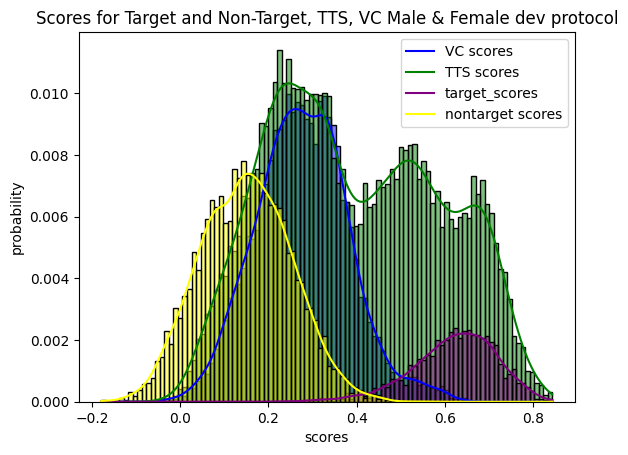

In [23]:
vc_filter = (results_list_dev_all['attack_type'] == "A05") | (results_list_dev_all['attack_type'] == "A06")
tts_filter = (results_list_dev_all['attack_type'] == "A01") | (results_list_dev_all['attack_type'] == "A02") | (results_list_dev_all['attack_type'] == "A03") | (results_list_dev_all['attack_type'] == "A04")


target_scores = results_list_dev_all.loc[results_list_dev_all['label_ground_truth'] == "target"]["pred_scores"]
nontarget_scores = results_list_dev_all.loc[results_list_dev_all['label_ground_truth'] == "nontarget"]["pred_scores"]
VC_scores = results_list_dev_all.loc[vc_filter]["pred_scores"]
TTS_scores = results_list_dev_all.loc[tts_filter]["pred_scores"]

plotting_probability_histogram_TTS_and_VC(nontarget_scores,target_scores,TTS_scores,VC_scores,combine_TTS_VC_scores=None,num_bins=100,colors=['yellow', 'purple','green','blue','brown'],data_name= f"Male & Female dev protocol")


### DCF - Male and Female:

In [24]:
from ASV_utils.dcf_my_functions import calculate_dcf
import matplotlib.pyplot as plt

Prior_target =  0.99

Prior_non_target = 1 - Prior_target

dcf_list_eval_all = []
is_print = True

cost_model_dcf = {
    'Cmiss_asv': 1,      # Cost of ASV falsely rejecting target
    'Cfa_asv': 10,       # Cost of ASV falsely accepting nontarget
}

all_enrollement_eval = enrollment_eval_male + enrollment_eval_female 

# for all eval
asv_thr_list = np.arange(0, 1.01, 0.001).tolist()

#results_list_eval_all = calculate_dcf_avg_score(list_eval_files,df_eval_all_protocol,all_enrollement_eval,embeddings_eval,Eval_dataset_all)

import pickle
file_path = 'asv_results_eval_fixed_all.pkl'

# Open the file in binary write mode and dump the data
# with open(file_path, 'wb') as f:
#     pickle.dump(results_list_eval_all, f)

target_scores = results_list_eval_all.loc[results_list_eval_all['label_ground_truth'] == "target"]["pred_scores"]
nontarget_scores = results_list_eval_all.loc[results_list_eval_all['label_ground_truth'] == "nontarget"]["pred_scores"]

eer, thr_eer, frr, far = eval_metrics.compute_eer(target_scores,nontarget_scores)
    
for asv_thr in asv_thr_list: # over each asv score

    print("current asv score is: ",asv_thr)

    Pfa_asv, Pmiss_asv, _ , _ = eval_metrics.obtain_asv_error_rates(target_scores,nontarget_scores,np.array([]),asv_thr)
    dcf = dcf_formula(Pfa_asv,Pmiss_asv,Prior_target = Prior_target,Prior_non_target= Prior_non_target,cost_model_dcf=cost_model_dcf,is_print=is_print)
    dcf_list_eval_all.append(dcf)
    
    
print("the EER is: ",eer)
print("the threshold of the EER is: ",thr_eer)
minDCF_index = np.argmin(np.array(dcf_list_eval_all))
print("the minDCF is:",dcf_list_eval_all[minDCF_index])
print("the threshold of the minDCF is: ",asv_thr_list[minDCF_index])

NameError: name 'results_list_eval_all' is not defined

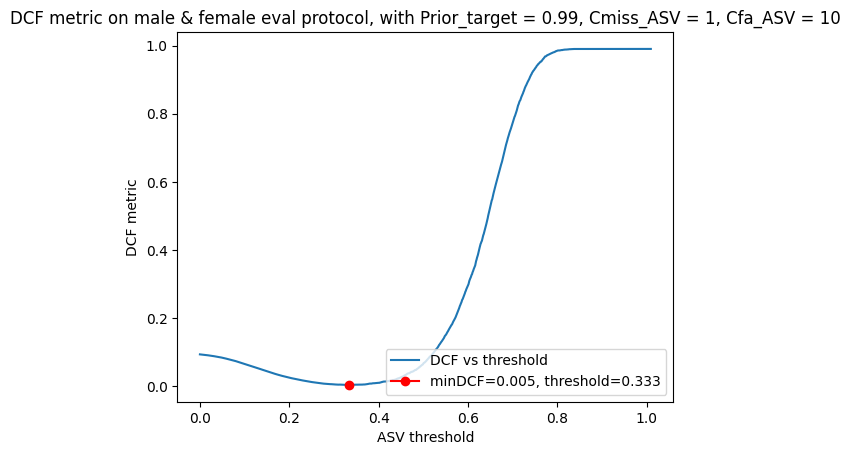

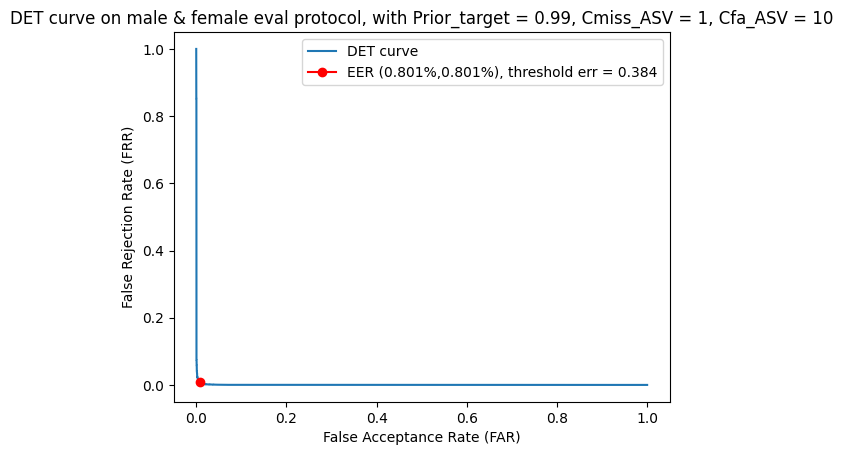

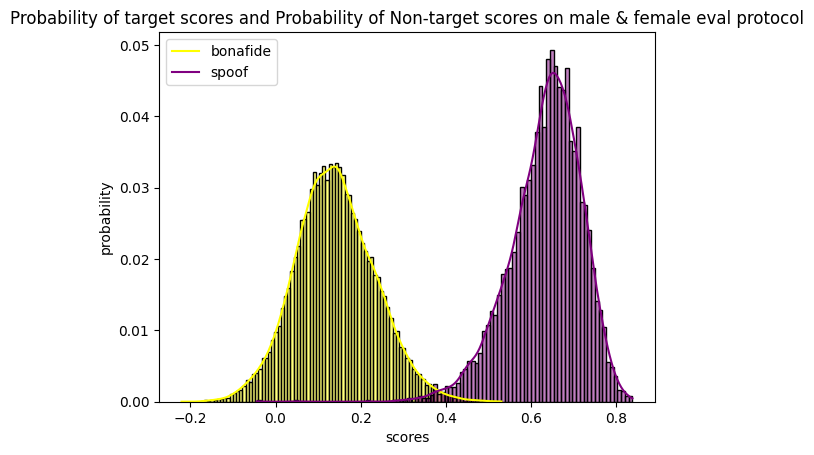

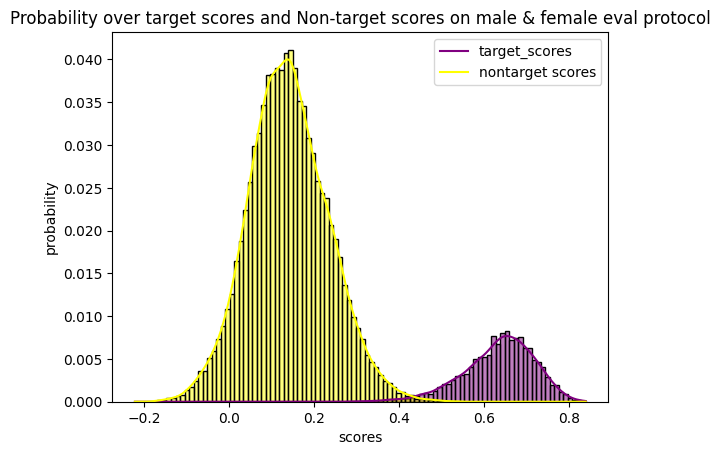

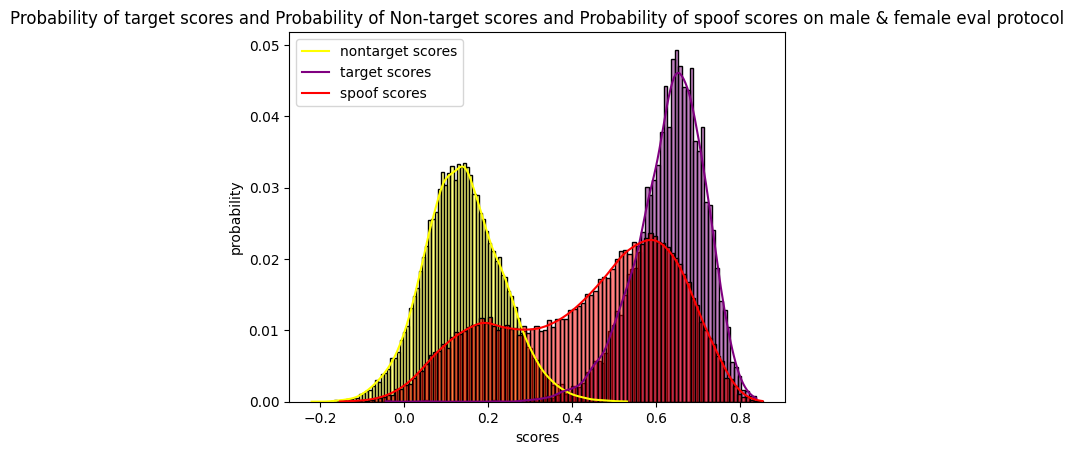

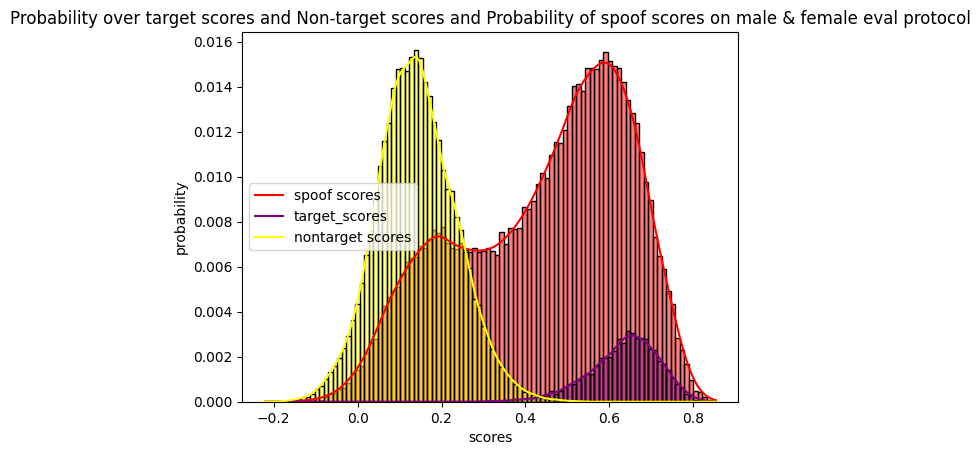

In [24]:
plotting_eer_and_dcf(asv_thr_list,dcf_list_eval_all,frr,far,eer,thr_eer,data_name = f"male & female eval protocol, with Prior_target = {Prior_target}, Cmiss_ASV = {cost_model_dcf['Cmiss_asv']}, Cfa_ASV = {cost_model_dcf['Cfa_asv']}")

target_scores = results_list_eval_all.loc[results_list_eval_all['label_ground_truth'] == "target"]["pred_scores"]
nontarget_scores = results_list_eval_all.loc[results_list_eval_all['label_ground_truth'] == "nontarget"]["pred_scores"]
spoof_scores = results_list_eval_all.loc[results_list_eval_all['label_ground_truth'] == "spoof"]["pred_scores"]

# Plot the histograms
plotting_probability_histogram(nontarget_scores,target_scores,num_bins=100,colors=['yellow', 'purple'],data_name = f"male & female eval protocol")
plotting_probability_histogram(nontarget_scores,target_scores,spoof_scores,num_bins=100,colors=['yellow', 'purple','red'],data_name = f"male & female eval protocol")




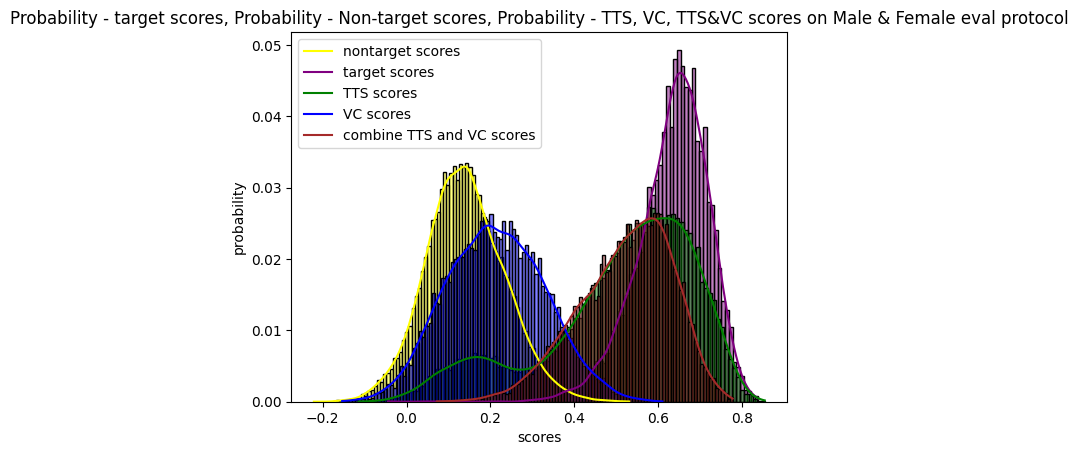

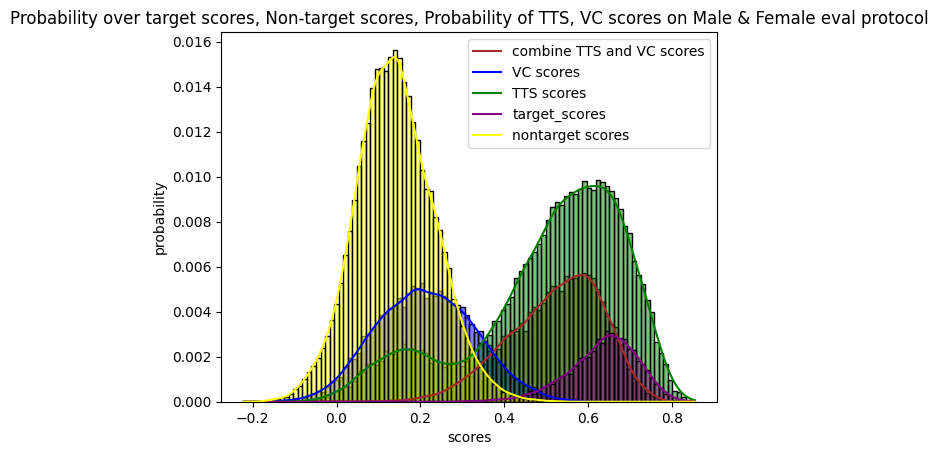

In [25]:

vc_filter = results_list_eval_all['attack_type'].isin(["A17", "A18", "A19"])
tts_filter = results_list_eval_all['attack_type'].isin(["A07", "A08", "A09", "A10","A11","A12","A16"])
combine_TTS_VC_filter = results_list_eval_all['attack_type'].isin(["A13", "A14", "A15"])

target_scores = results_list_eval_all.loc[results_list_eval_all['label_ground_truth'] == "target"]["pred_scores"]
nontarget_scores = results_list_eval_all.loc[results_list_eval_all['label_ground_truth'] == "nontarget"]["pred_scores"]
VC_scores = results_list_eval_all.loc[vc_filter]["pred_scores"]
TTS_scores = results_list_eval_all.loc[tts_filter]["pred_scores"]
combine_TTS_VC_scores = results_list_eval_all.loc[combine_TTS_VC_filter]["pred_scores"]


plotting_probability_histogram_TTS_and_VC(nontarget_scores,target_scores,TTS_scores,VC_scores,combine_TTS_VC_scores,num_bins=100,colors=['yellow', 'purple','green','blue','brown'],data_name= f"Male & Female eval protocol")

# Using The ASVSpoof2019 file challenge:

In [4]:
def plotting_eer_and_dcf(asv_score_list,dcf_list,frr,far,eer,thr_eer,data_name = None):
    if data_name is None:
        raise Exception("Please insert data name")
    plt.figure()
    plt.plot(asv_score_list,dcf_list, label = 'DCF vs threshold')
    minDCF_index = np.argmin(np.array(dcf_list))
    plt.plot(asv_score_list[minDCF_index],dcf_list[minDCF_index],color ='red', marker = 'o',label =f'minDCF={dcf_list[minDCF_index]:.3f}, threshold={asv_score_list[minDCF_index]:.3f}')
    plt.title(f"DCF metric on " + data_name)
    plt.ylabel("DCF metric")
    plt.xlabel("ASV threshold")
    plt.legend(loc = 'upper right')
    plt.show()

    plt.figure()
    plt.plot(frr,far,label ='DET curve')
    plt.plot(eer,eer,color ='red', marker = 'o',label =f'EER ({100*eer:.3f}%,{100*eer:.3f}%), threshold err = {thr_eer:.3f}')
    plt.ylabel("False Rejection Rate (FRR)")
    plt.xlabel("False Acceptance Rate (FAR)")
    plt.title("DET curve on " + data_name)
    plt.legend(loc = 'upper right')
    plt.show()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import utils.eval_metrics as eval_metrics 
def read_txt_ASV2019_scores(file_path):
    is_spoofed = []
    label = []
    score = []
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split(' ')
            if len(parts) != 3:
                raise Exception("The line in the file is not in the right format")
            is_spoofed.append(parts[0])
            label.append(parts[1])
            score.append(parts[2])
            
    return pd.Series(is_spoofed), pd.Series(label), pd.Series(score)

In [6]:
file_path ="./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.gi.trl.scores.txt"
 
ASV2019_attack_type ,ASV2019_label,ASV2019_scores  = read_txt_ASV2019_scores(file_path)

In [7]:
ASV2019_scores = ASV2019_scores.astype(float)

In [8]:
# Manually normalizing to [0, 1]
ASV2019_scores = (ASV2019_scores - ASV2019_scores.min()) / (ASV2019_scores.max() - ASV2019_scores.min())


In [9]:
vc_filter = ASV2019_attack_type.isin(["A17", "A18", "A19"])
tts_filter = ASV2019_attack_type.isin(["A07", "A08", "A09", "A10","A11","A12","A16"])
combine_TTS_VC_filter = ASV2019_attack_type.isin(["A13", "A14", "A15"])


In [10]:

target_scores = ASV2019_scores[ASV2019_label == "target"].astype(float)
nontarget_scores = ASV2019_scores[ASV2019_label == "nontarget"].astype(float)
VC_scores = ASV2019_scores[vc_filter].astype(float)
TTS_scores = ASV2019_scores[tts_filter].astype(float)
combine_TTS_VC_scores = ASV2019_scores[combine_TTS_VC_filter].astype(float)


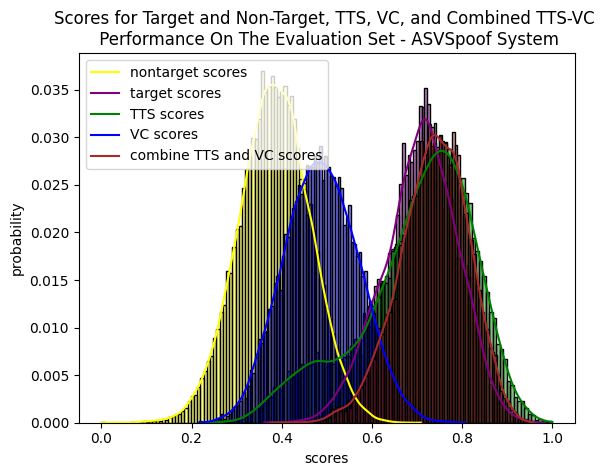

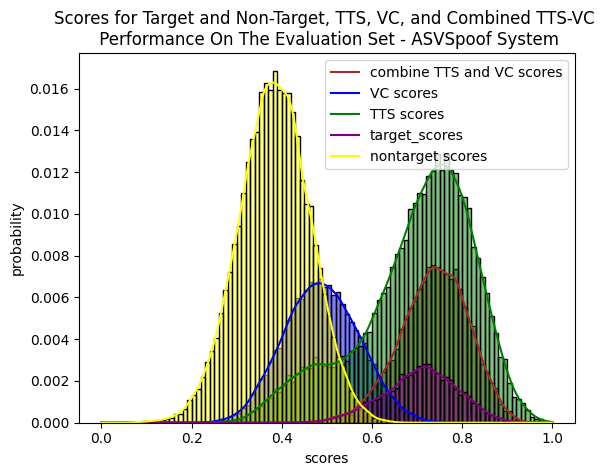

In [32]:
plotting_probability_histogram_TTS_and_VC(nontarget_scores,target_scores,TTS_scores,VC_scores,combine_TTS_VC_scores,num_bins=100,colors=['yellow', 'purple','green','blue','brown'],data_name= f"\n Performance On The Evaluation Set - ASVSpoof System")

current asv score is:  -1.0
The DCF is:  0.10000000000000009
current asv score is:  -0.999
The DCF is:  0.10000000000000009
current asv score is:  -0.998
The DCF is:  0.10000000000000009
current asv score is:  -0.997
The DCF is:  0.10000000000000009
current asv score is:  -0.996
The DCF is:  0.10000000000000009
current asv score is:  -0.995
The DCF is:  0.10000000000000009
current asv score is:  -0.994
The DCF is:  0.10000000000000009
current asv score is:  -0.993
The DCF is:  0.10000000000000009
current asv score is:  -0.992
The DCF is:  0.10000000000000009
current asv score is:  -0.991
The DCF is:  0.10000000000000009
current asv score is:  -0.99
The DCF is:  0.10000000000000009
current asv score is:  -0.989
The DCF is:  0.10000000000000009
current asv score is:  -0.988
The DCF is:  0.10000000000000009
current asv score is:  -0.987
The DCF is:  0.10000000000000009
current asv score is:  -0.986
The DCF is:  0.10000000000000009
current asv score is:  -0.985
The DCF is:  0.1000000000000

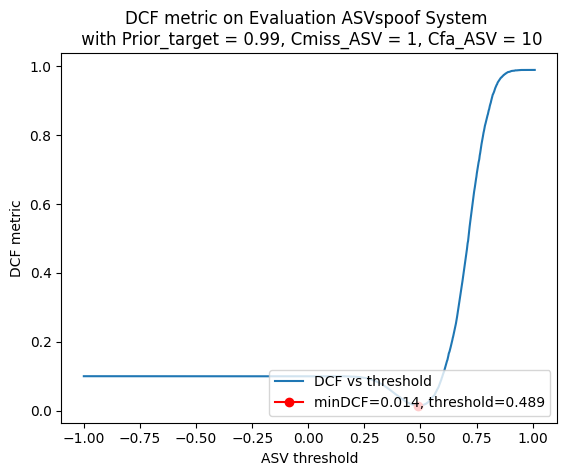

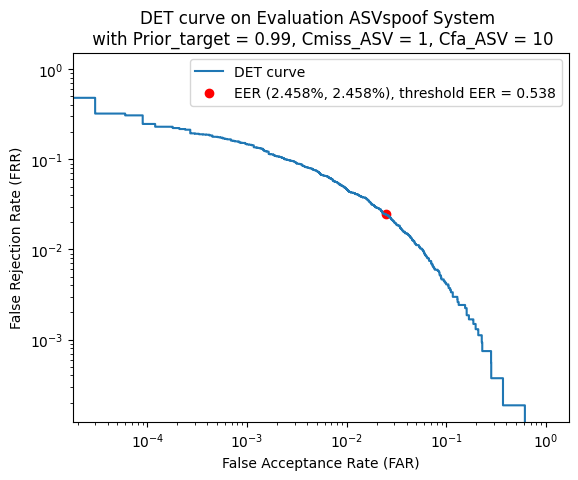

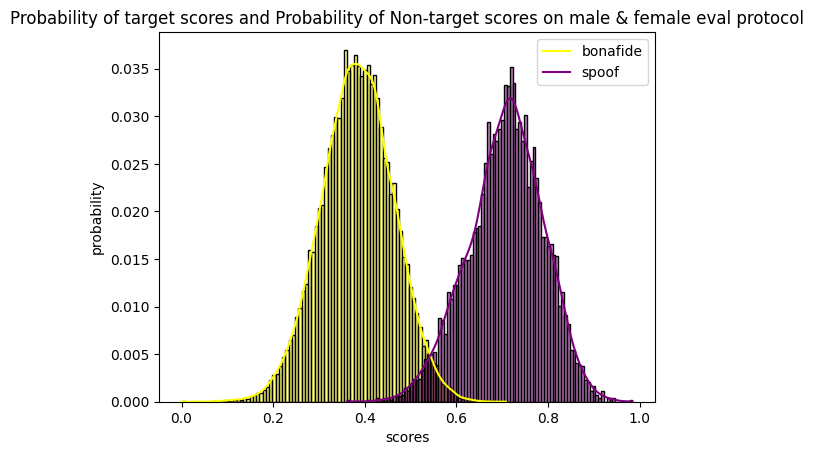

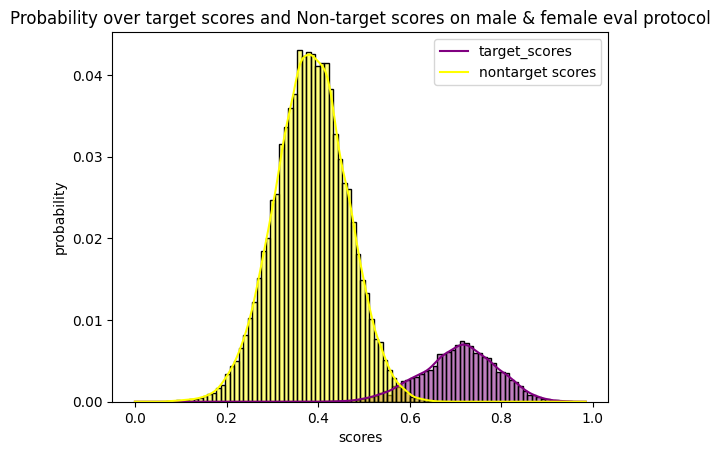

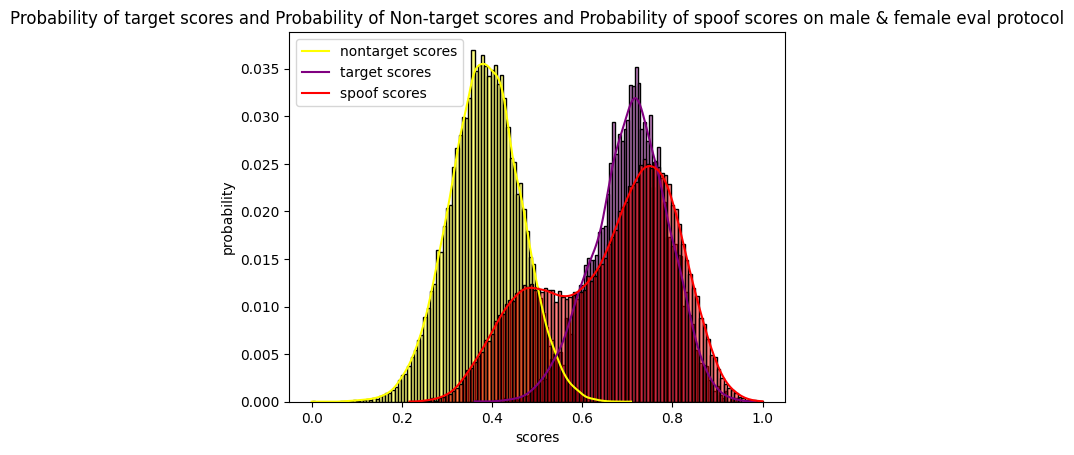

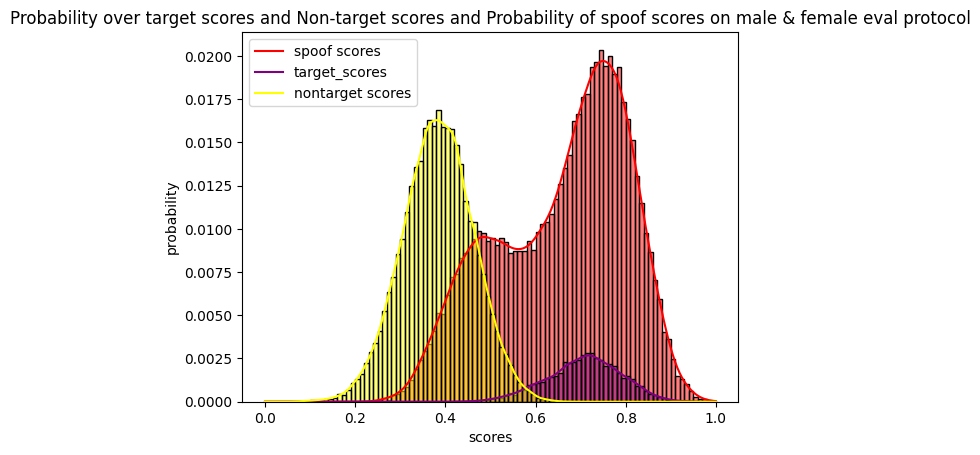

In [14]:
from ASV_utils.dcf_my_functions import calculate_dcf
import matplotlib.pyplot as plt
from ASV_utils.dcf_my_functions import dcf_formula

Prior_target =  0.99

Prior_non_target = 1 - Prior_target

dcf_list_eval_all = []
is_print = True

cost_model_dcf = {
    'Cmiss_asv': 1,      # Cost of ASV falsely rejecting target
    'Cfa_asv': 10,       # Cost of ASV falsely accepting nontarget
}

asv_thr_list = np.arange(-1, 1.01, 0.001).tolist()

target_scores = ASV2019_scores[ASV2019_label == "target"].astype(float)
nontarget_scores = ASV2019_scores[ASV2019_label == "nontarget"].astype(float)

eer, thr_eer, frr, far = eval_metrics.compute_eer(target_scores,nontarget_scores)
    
for asv_thr in asv_thr_list: # over each asv score

    print("current asv score is: ",asv_thr)

    Pfa_asv, Pmiss_asv, _ , _ = eval_metrics.obtain_asv_error_rates(target_scores,nontarget_scores,np.array([]),asv_thr)
    dcf = dcf_formula(Pfa_asv,Pmiss_asv,Prior_target = Prior_target,Prior_non_target= Prior_non_target,cost_model_dcf=cost_model_dcf,is_print=is_print)
    dcf_list_eval_all.append(dcf)
    
    
print("the EER is: ",eer)
print("the threshold of the EER is: ",thr_eer)
minDCF_index = np.argmin(np.array(dcf_list_eval_all))
print("the minDCF is:",dcf_list_eval_all[minDCF_index])
print("the threshold of the minDCF is: ",asv_thr_list[minDCF_index])

plotting_eer_and_dcf(asv_thr_list,dcf_list_eval_all,frr,far,eer,thr_eer,data_name = f"Evaluation ASVspoof System \n with Prior_target = {Prior_target}, Cmiss_ASV = {cost_model_dcf['Cmiss_asv']}, Cfa_ASV = {cost_model_dcf['Cfa_asv']}")

target_scores = ASV2019_scores[ASV2019_label == "target"].astype(float)
nontarget_scores = ASV2019_scores[ASV2019_label == "nontarget"].astype(float)
spoof_scores = ASV2019_scores[ASV2019_label == "spoof"].astype(float)

# Plot the histograms
plotting_probability_histogram(nontarget_scores,target_scores,num_bins=100,colors=['yellow', 'purple'],data_name = f"male & female eval protocol")
plotting_probability_histogram(nontarget_scores,target_scores,spoof_scores,num_bins=100,colors=['yellow', 'purple','red'],data_name = f"male & female eval protocol")



In [15]:
file_path ="./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.gi.trl.scores.txt"
 
ASV2019_attack_type ,ASV2019_label,ASV2019_scores  = read_txt_ASV2019_scores(file_path)

ASV2019_scores =  ASV2019_scores.astype(float)

ASV2019_scores = (ASV2019_scores - ASV2019_scores.min()) / (ASV2019_scores.max() - ASV2019_scores.min())

vc_filter = ASV2019_attack_type.isin(["A05", "A06"])
tts_filter = ASV2019_attack_type.isin(["A01", "A02", "A03", "A04"])



target_scores = ASV2019_scores[ASV2019_label == "target"].astype(float)
nontarget_scores = ASV2019_scores[ASV2019_label == "nontarget"].astype(float)
VC_scores = ASV2019_scores[vc_filter].astype(float)
TTS_scores = ASV2019_scores[tts_filter].astype(float)
combine_TTS_VC_scores = None



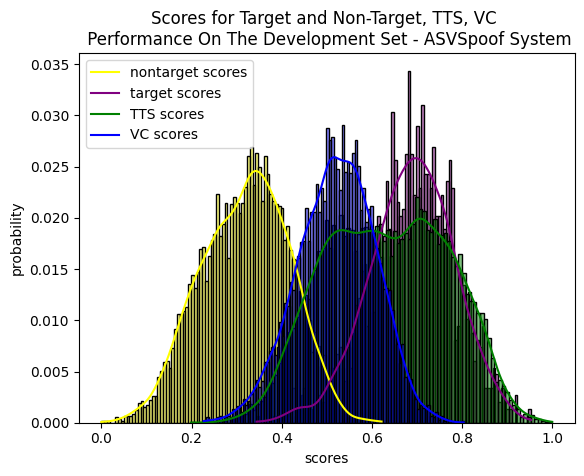

C:\Users\avish\AppData\Local\Temp\ipykernel_27352\981316493.py:19: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.histplot([nontarget_scores.to_numpy(), target_scores.to_numpy(),TTS_scores.to_numpy(),VC_scores.to_numpy()], kde=True, stat='probability', bins=100, palette=colors, linewidth=1)# Add labels and title


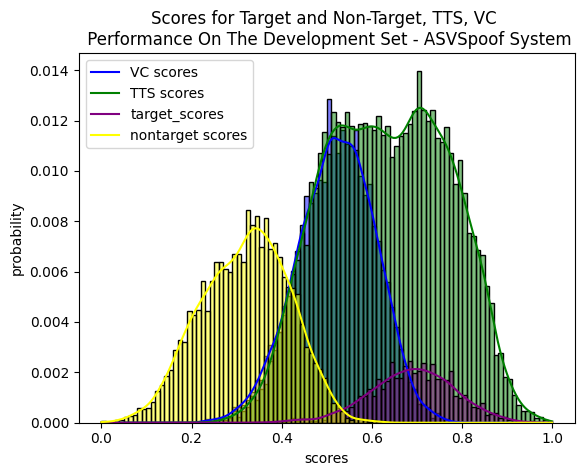

In [21]:
plotting_probability_histogram_TTS_and_VC(nontarget_scores,target_scores,TTS_scores,VC_scores,combine_TTS_VC_scores,num_bins=100,colors=['yellow', 'purple','green','blue','brown'],data_name= f"\n Performance On The Development Set - ASVSpoof System")

current asv score is:  -1.0
The DCF is:  0.10000000000000009
current asv score is:  -0.999
The DCF is:  0.10000000000000009
current asv score is:  -0.998
The DCF is:  0.10000000000000009
current asv score is:  -0.997
The DCF is:  0.10000000000000009
current asv score is:  -0.996
The DCF is:  0.10000000000000009
current asv score is:  -0.995
The DCF is:  0.10000000000000009
current asv score is:  -0.994
The DCF is:  0.10000000000000009
current asv score is:  -0.993
The DCF is:  0.10000000000000009
current asv score is:  -0.992
The DCF is:  0.10000000000000009
current asv score is:  -0.991
The DCF is:  0.10000000000000009
current asv score is:  -0.99
The DCF is:  0.10000000000000009
current asv score is:  -0.989
The DCF is:  0.10000000000000009
current asv score is:  -0.988
The DCF is:  0.10000000000000009
current asv score is:  -0.987
The DCF is:  0.10000000000000009
current asv score is:  -0.986
The DCF is:  0.10000000000000009
current asv score is:  -0.985
The DCF is:  0.1000000000000

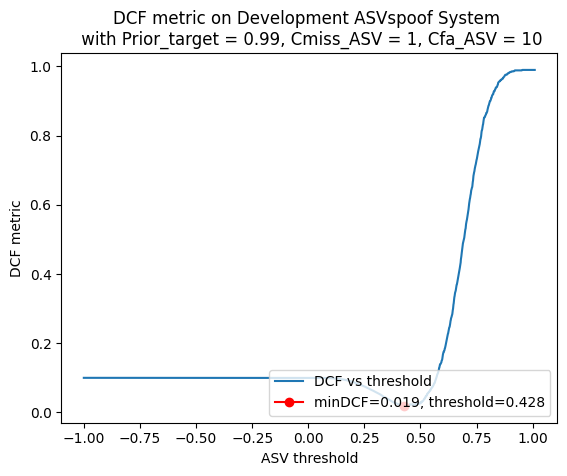

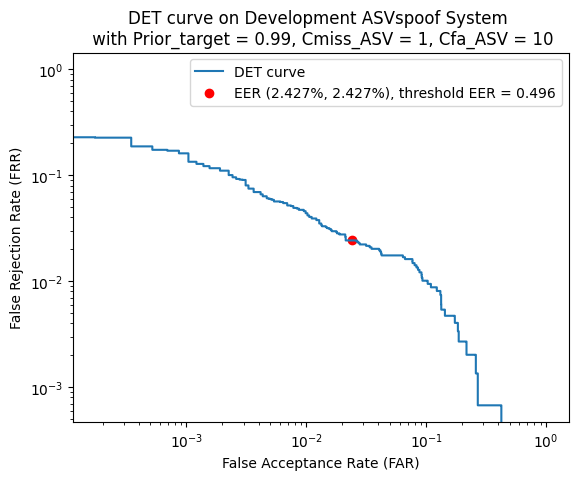

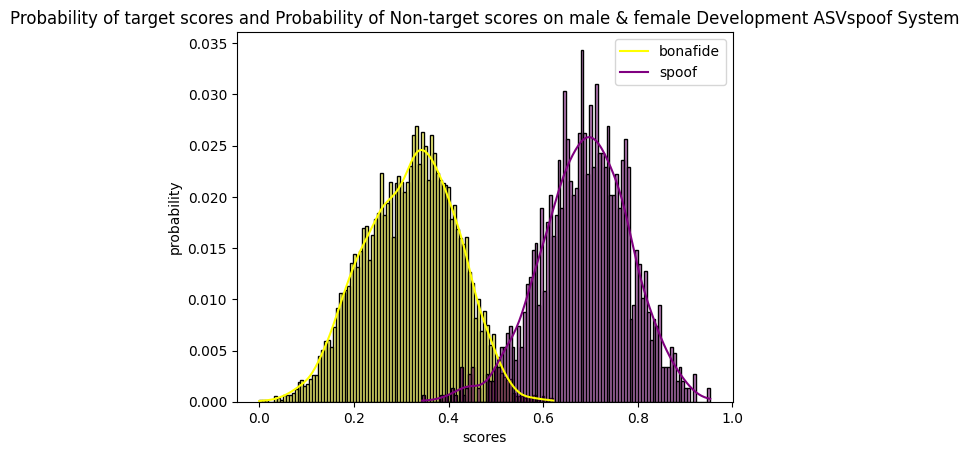

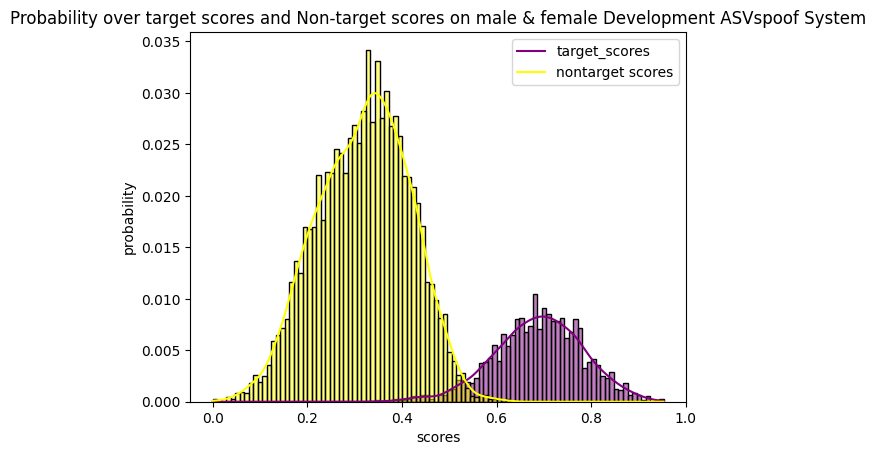

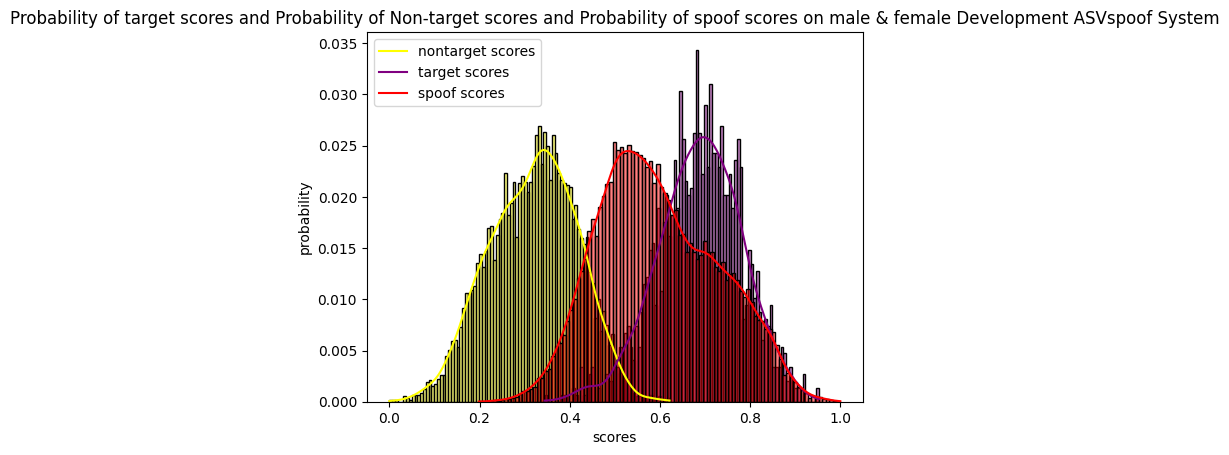

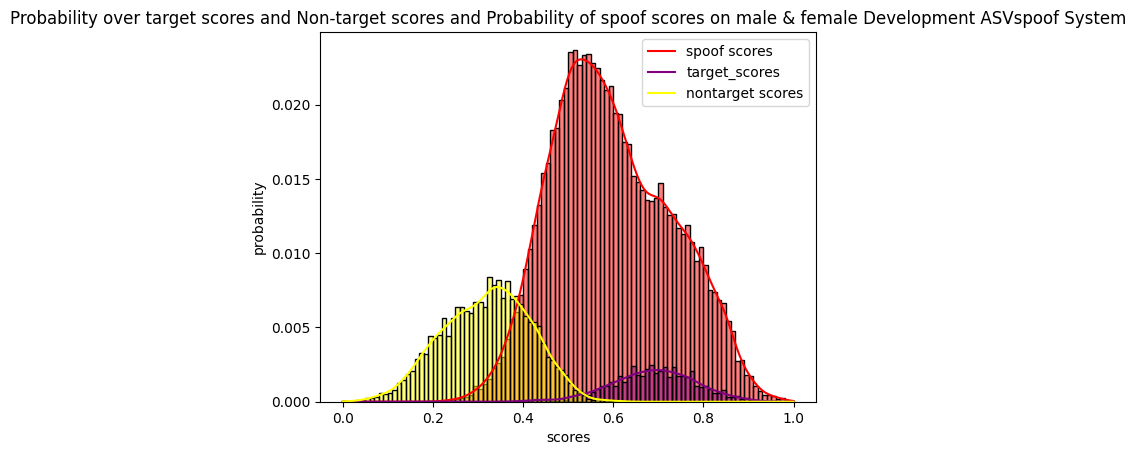

In [22]:
from ASV_utils.dcf_my_functions import calculate_dcf
import matplotlib.pyplot as plt
from ASV_utils.dcf_my_functions import dcf_formula

Prior_target =  0.99

Prior_non_target = 1 - Prior_target

dcf_list_eval_all = []
is_print = True

cost_model_dcf = {
    'Cmiss_asv': 1,      # Cost of ASV falsely rejecting target
    'Cfa_asv': 10,       # Cost of ASV falsely accepting nontarget
}

asv_thr_list = np.arange(-1, 1.01, 0.001).tolist()

target_scores = ASV2019_scores[ASV2019_label == "target"].astype(float)
nontarget_scores = ASV2019_scores[ASV2019_label == "nontarget"].astype(float)

eer, thr_eer, frr, far = eval_metrics.compute_eer(target_scores,nontarget_scores)
    
for asv_thr in asv_thr_list: # over each asv score

    print("current asv score is: ",asv_thr)

    Pfa_asv, Pmiss_asv, _ , _ = eval_metrics.obtain_asv_error_rates(target_scores,nontarget_scores,np.array([]),asv_thr)
    dcf = dcf_formula(Pfa_asv,Pmiss_asv,Prior_target = Prior_target,Prior_non_target= Prior_non_target,cost_model_dcf=cost_model_dcf,is_print=is_print)
    dcf_list_eval_all.append(dcf)
    
    
print("the EER is: ",eer)
print("the threshold of the EER is: ",thr_eer)
minDCF_index = np.argmin(np.array(dcf_list_eval_all))
print("the minDCF is:",dcf_list_eval_all[minDCF_index])
print("the threshold of the minDCF is: ",asv_thr_list[minDCF_index])

plotting_eer_and_dcf(asv_thr_list,dcf_list_eval_all,frr,far,eer,thr_eer,data_name = f"Development ASVspoof System \n with Prior_target = {Prior_target}, Cmiss_ASV = {cost_model_dcf['Cmiss_asv']}, Cfa_ASV = {cost_model_dcf['Cfa_asv']}")

target_scores = ASV2019_scores[ASV2019_label == "target"].astype(float)
nontarget_scores = ASV2019_scores[ASV2019_label == "nontarget"].astype(float)
spoof_scores = ASV2019_scores[ASV2019_label == "spoof"].astype(float)

# Plot the histograms
plotting_probability_histogram(nontarget_scores,target_scores,num_bins=100,colors=['yellow', 'purple'],data_name = f"male & female Development ASVspoof System")
plotting_probability_histogram(nontarget_scores,target_scores,spoof_scores,num_bins=100,colors=['yellow', 'purple','red'],data_name = f"male & female Development ASVspoof System")

